# Target Plots for Diss

**Aufbau**
1. Setup & Daten laden
2. Datenverfügbarkeit & überlappender Zeitraum (fairer Vergleich)
3. Training: Lernkurven
4. Fertiges System: Marktpreis & Profit
5. Action-Value Exploration
6. Price Duration Curves
7. Dispatch
8. Market Clearing
9. Battery Dispatch

**Konvention zu den Simulationen**
- `SIM_TRAIN` = Trainingslauf mit allen Episoden → alle *Trainings*-Plots
- `SIM_RL`    = fertig trainiertes System (Dispatch) → alle *fertiges-System*-Plots (Profit, Preise, Duration Curves)
- `SIM_HEU`   = Heuristik-Referenz

In [1]:
# Module imports
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from sqlalchemy import create_engine, inspect

import examples as examples

2026-06-16 12:05:40.848954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 12:05:40.862263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781604340.875988  792841 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781604340.880044  792841 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781604340.891702  792841 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# In das Repo-Root wechseln, damit relative Pfade (examples/...) stimmen
if current_dir := os.path.basename(os.getcwd()) == "future_markets_paper":
    %cd ../..
elif current_dir := os.path.basename(os.getcwd()) == "examples":
    %cd ..

/hkfs/work/workspace_haic/scratch/tg3533-assume_case/tg3533-assume_case_restored-1780882813/tg3533-assume_case-1770084722/assume


In [3]:
example = "case_study_2013_pp"
db_uri = "sqlite:///./examples/local_db/assume_db_pp.db"
inputs_dir = "examples/inputs"

scenario = examples.available_examples[example]["scenario"]

# ── Zentrale Simulations-Namen ───────────────────────────────────────────────
# Trainingslauf: enthaelt die einzelnen Episoden + eval-Episoden
SIM_TRAIN = "future_markets_paper_base_case_2013_pp_all"
# Fertig trainiertes RL-System (Dispatch mit final policy)
SIM_RL    = "future_markets_paper_base_case_2013_pp_all_kurz_dispatch"
# Heuristik-Referenz
SIM_HEU   = "future_markets_paper_base_case_2013_heu"

# Simulationen, die im Vergleich des *fertigen Systems* auftauchen
# (Profit, Marktpreis, Price-Duration-Curves, Dispatch)
FINAL_SIMS = [SIM_HEU, SIM_RL]

# Validierungs-Intervall (jede n-te Episode wird evaluiert) -> fuer x-Achse der Eval-Punkte
EVAL_INTERVAL = 10

# Datenbankverbindung
db = create_engine(db_uri)

## 1. Setup & Daten laden

In [4]:
# Vorhandene Tabellen anzeigen
inspector = inspect(db)
print(inspector.get_table_names())

['demand_meta', 'kpis', 'market_dispatch', 'market_meta', 'market_orders', 'power_plant_meta', 'rl_grad_params', 'rl_meta', 'rl_params', 'storage_meta', 'unit_dispatch']


In [5]:
# market_meta (realisierte Marktergebnisse je Zeitschritt) + KPIs
market_meta_df = pd.read_sql("SELECT * FROM market_meta", db)
market_meta_df["time"] = pd.to_datetime(market_meta_df["time"])

kpis = pd.read_sql("SELECT * FROM kpis", db)

print("Simulationen in market_meta:")
print(market_meta_df["simulation"].unique())

Simulationen in market_meta:
['future_markets_paper_base_case_2013_heu'
 'future_markets_paper_base_case_2013_pp_all'
 'future_markets_paper_base_case_2013_pp_all_kurz_dispatch']


In [6]:
# Technologie-Mapping je Unit (fuer Dispatch- und Price-Setter-Plots)
power_plant_meta = pd.read_sql("SELECT * FROM power_plant_meta", db)[["index", "fuel_type"]]
power_plant_meta = power_plant_meta.rename(columns={"fuel_type": "technology"})
storage_meta = pd.read_sql("SELECT * FROM storage_meta", db)[["index", "technology"]]

all_meta = pd.concat([power_plant_meta, storage_meta], ignore_index=True)
all_meta = all_meta.rename(columns={"index": "unit_id"})
all_meta_unique = all_meta.drop_duplicates(subset="unit_id", keep="first")[["unit_id", "technology"]]

In [7]:
# Unit-Dispatch (alle Simulationen) inkl. Technologie
dispatch_df = pd.read_sql("SELECT * FROM unit_dispatch", db)
dispatch_df = dispatch_df.drop_duplicates(subset=["time", "unit", "simulation"], keep="first")
dispatch_df["time"] = pd.to_datetime(dispatch_df["time"])
dispatch_df = dispatch_df.sort_values("time")

dispatch_df = dispatch_df.merge(all_meta_unique, left_on="unit", right_on="unit_id", how="left")
dispatch_df["technology"] = dispatch_df["technology"].fillna(dispatch_df["unit"])

In [8]:
# Forecast (Referenzpreise)
forecast_df = pd.read_csv(
    "examples/inputs/future_markets_paper/forecasts_df.csv",
    index_col=0, parse_dates=True,
)
forecast_df.index.name = "datetime"
forecast_df = forecast_df.reset_index()

## 2. Datenverfügbarkeit & überlappender Zeitraum

Die Heuristik (`SIM_HEU`) liegt über einen **längeren Zeitraum** vor als das finale RL-System (`SIM_RL`).
Damit Vergleiche (Profit, Preise, Dispatch) fair sind, schneiden wir alle „fertiges-System"-Auswertungen
auf das **gemeinsame Zeitfenster** zu. Die Helper-Funktion `clip_to_overlap()` macht das für jeden DataFrame
mit einer Zeit-Spalte.

In [9]:
# Datenverfuegbarkeit je Simulation aus market_meta
avail = (
    market_meta_df.groupby("simulation")["time"]
    .agg(start="min", end="max", n="count")
    .reset_index()
    .sort_values("start")
)

final_bounds = avail[avail["simulation"].isin(FINAL_SIMS)]
print("Datenverfuegbarkeit der zu vergleichenden Simulationen:")
for _, r in final_bounds.iterrows():
    print(f"  {r['simulation']:<55} {r['start']}  ->  {r['end']}  ({r['n']} Zeilen)")

missing = set(FINAL_SIMS) - set(final_bounds["simulation"])
if missing:
    print("\nWARNUNG: keine market_meta-Daten fuer:", missing)

# Ueberlappendes Zeitfenster ueber FINAL_SIMS
overlap_start = final_bounds["start"].max()
overlap_end   = final_bounds["end"].min()
print(f"\nUeberlappender Zeitraum: {overlap_start}  ->  {overlap_end}")


def clip_to_overlap(df, time_col="time"):
    """Beschneidet einen DataFrame auf das gemeinsame Zeitfenster der FINAL_SIMS."""
    t = pd.to_datetime(df[time_col])
    return df[(t >= overlap_start) & (t <= overlap_end)].copy()


# Forecast-Durchschnittspreis im Ueberlappungsfenster (faire Referenz fuer alle Plots)
forecast_overlap = forecast_df[
    (forecast_df["datetime"] >= overlap_start) & (forecast_df["datetime"] <= overlap_end)
]
avg_forecast_price = forecast_overlap["price_EOM"].mean()
print(f"O Forecast-Preis (Ueberlappung): {avg_forecast_price:.2f} EUR/MWh")

Datenverfuegbarkeit der zu vergleichenden Simulationen:
  future_markets_paper_base_case_2013_heu                 2013-01-01 01:00:00  ->  2013-02-27 23:00:00  (1391 Zeilen)
  future_markets_paper_base_case_2013_pp_all_kurz_dispatch 2013-01-22 01:00:00  ->  2013-02-02 23:00:00  (287 Zeilen)

Ueberlappender Zeitraum: 2013-01-22 01:00:00  ->  2013-02-02 23:00:00
O Forecast-Preis (Ueberlappung): 60.90 EUR/MWh


## 3. Training: Lernkurven

Pro (Eval-)Episode aus `kpis` für den Trainingslauf `SIM_TRAIN`.
Heuristik und Forecast haben keinen Lernprozess → horizontale Referenzlinien,
beide über das **Überlappungsfenster** berechnet.

In [10]:
def parse_episode(sim_str):
    """Gibt (episode_number, is_eval) aus einem simulation-String zurueck."""
    m = re.search(r"eval_episode_(\d+)$", sim_str)
    if m:
        return int(m.group(1)), True
    m = re.search(r"episode_(\d+)$", sim_str)
    if m:
        return int(m.group(1)), False
    return None, None


def get_episode_kpi(variable):
    """Holt eine KPI-Variable pro Episode des Trainingslaufs als (train, eval) DataFrames."""
    d = kpis[
        kpis["simulation"].str.startswith(SIM_TRAIN) & (kpis["variable"] == variable)
    ].copy()
    d[["episode", "is_eval"]] = d["simulation"].apply(lambda s: pd.Series(parse_episode(s)))
    d = d.dropna(subset=["episode"])
    d["episode"] = d["episode"].astype(int)
    return d[~d["is_eval"]].sort_values("episode"), d[d["is_eval"]].sort_values("episode")


# Heuristik-Referenz: avg_price im Ueberlappungsfenster (aus market_meta, NICHT aus kpis,
# damit der laengere Heuristik-Zeitraum den Vergleich nicht verzerrt)
avg_price_heu = clip_to_overlap(
    market_meta_df[market_meta_df["simulation"] == SIM_HEU]
)["price"].mean()

In [11]:
# Lernkurve: durchschnittlicher Marktpreis
train_avg, eval_avg = get_episode_kpi("avg_price")

fig_lc = go.Figure()
fig_lc.add_trace(go.Scatter(
    x=train_avg["episode"], y=train_avg["value"],
    mode="lines+markers", name="RL Training",
    line=dict(color="#3C3489", width=1.5), marker=dict(size=4), opacity=0.7,
))
if not eval_avg.empty:
    fig_lc.add_trace(go.Scatter(
        x=eval_avg["episode"] * EVAL_INTERVAL, y=eval_avg["value"],
        mode="markers", name="RL Eval",
        marker=dict(color="#5B8FD4", size=7, symbol="diamond"),
    ))
fig_lc.add_hline(y=avg_price_heu, line=dict(color="#854F0B", width=2, dash="dash"),
                 annotation_text="Heuristik", annotation_position="top right")
fig_lc.add_hline(y=avg_forecast_price, line=dict(color="#888888", width=2, dash="dot"),
                 annotation_text="Forecast", annotation_position="bottom right")
fig_lc.update_layout(
    title="Lernkurve: Durchschnittlicher Marktpreis ueber Episoden",
    xaxis_title="Episode", yaxis_title="O Preis (EUR/MWh)", height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig_lc.show()

In [12]:
# Lernkurve: Min- & Max-Marktpreis
fig_minmax = go.Figure()

for variable, color_train, color_eval, label in [
    ("min_price", "#C0392B", "#E8A09A", "Min Price"),
    ("max_price", "#1A5276", "#5B8FD4", "Max Price"),
]:
    train_mm, eval_mm = get_episode_kpi(variable)
    fig_minmax.add_trace(go.Scatter(
        x=train_mm["episode"], y=train_mm["value"],
        mode="lines+markers", name=f"{label} Training",
        line=dict(color=color_train, width=1.5), marker=dict(size=4), opacity=0.7,
    ))
    if not eval_mm.empty:
        fig_minmax.add_trace(go.Scatter(
            x=eval_mm["episode"] * EVAL_INTERVAL, y=eval_mm["value"],
            mode="markers", name=f"{label} Eval",
            marker=dict(color=color_eval, size=7, symbol="diamond"),
        ))

# Forecast Min/Max ueber das Ueberlappungsfenster
for agg_fn, color, label, pos in [
    ("min", "#888888", "Forecast Min", "bottom right"),
    ("max", "#444444", "Forecast Max", "top right"),
]:
    val = getattr(forecast_overlap["price_EOM"], agg_fn)()
    fig_minmax.add_hline(y=val, line=dict(color=color, width=2, dash="dot"),
                         annotation_text=label, annotation_position=pos)

fig_minmax.update_layout(
    title="Lernkurve: Min & Max Marktpreis ueber Episoden",
    xaxis_title="Episode", yaxis_title="Preis (EUR/MWh)", height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig_minmax.show()

## 4. Fertiges System: Marktpreis & Profit

Alle Auswertungen hier nutzen `FINAL_SIMS` (`SIM_HEU` vs. `SIM_RL`) und werden mit
`clip_to_overlap()` auf das gemeinsame Zeitfenster beschnitten.

In [13]:
# Durchschnittlicher Marktpreis je Simulation (Ueberlappungsfenster)
LABELS = {SIM_HEU: "Heuristik", SIM_RL: "RL (final)"}
COLORS = {SIM_HEU: "#854F0B", SIM_RL: "#3C3489"}

avg_prices = {
    sim: clip_to_overlap(market_meta_df[market_meta_df["simulation"] == sim])["price"].mean()
    for sim in FINAL_SIMS
}

fig_avg = go.Figure()
for sim in FINAL_SIMS:
    fig_avg.add_trace(go.Bar(x=[LABELS[sim]], y=[avg_prices[sim]],
                             name=LABELS[sim], marker_color=COLORS[sim]))
fig_avg.add_trace(go.Bar(x=["Forecast"], y=[avg_forecast_price],
                         name="Forecast", marker_color="#888888"))
fig_avg.update_layout(title="Durchschnittlicher Marktpreis (Ueberlappungsfenster)",
                      yaxis_title="Preis (EUR/MWh)", barmode="group", height=400)
fig_avg.show()

In [14]:
# Profit je Unit: nur FINAL_SIMS, beschnitten aufs gemeinsame Fenster
dispatch_final = clip_to_overlap(dispatch_df[dispatch_df["simulation"].isin(FINAL_SIMS)])

profit_df = (
    dispatch_final.groupby(["unit", "simulation"])
    .agg(energy_cashflow=("energy_cashflow", "sum"),
         total_costs=("total_costs", "sum"))
    .reset_index()
)
profit_df["profit"] = profit_df["energy_cashflow"] - profit_df["total_costs"]

# Pivot: Heuristik vs. finales RL-System
df_pivot = (
    profit_df.pivot(index="unit", columns="simulation", values="profit")
    .dropna(subset=[SIM_HEU, SIM_RL])
    .reset_index()
)
df_pivot["diff"] = df_pivot[SIM_RL] - df_pivot[SIM_HEU]
df_pivot = df_pivot.sort_values("diff")

fig_profit_diff = go.Figure()
fig_profit_diff.add_trace(go.Bar(
    x=df_pivot["unit"], y=df_pivot["diff"],
    marker_color=df_pivot["diff"].apply(lambda x: "#378ADD" if x >= 0 else "#D85A30"),
    name="RL - Heuristik",
))
fig_profit_diff.update_layout(
    xaxis_title="Unit", yaxis_title="Profit Difference [EUR]",
    title="Profit-Differenz: RL (final) - Heuristik",
    hovermode="x unified", height=500,
    xaxis=dict(rangeslider=dict(visible=True)),
)
fig_profit_diff.show()

In [15]:
# Zeitreihe: Supply/Demand-Volumen + Preis je Simulation (Ueberlappungsfenster)
fig_ts = go.Figure()
for sim in FINAL_SIMS:
    d = clip_to_overlap(market_meta_df[market_meta_df["simulation"] == sim])
    fig_ts.add_trace(go.Scatter(x=d["time"], y=d["supply_volume_energy"],
                                name=f"Supply ({LABELS[sim]})", line=dict(color=COLORS[sim]), yaxis="y1"))
    fig_ts.add_trace(go.Scatter(x=d["time"], y=d["demand_volume_energy"],
                                name=f"Demand ({LABELS[sim]})", line=dict(color=COLORS[sim], dash="dash"), yaxis="y1"))
    fig_ts.add_trace(go.Scatter(x=d["time"], y=d["price"],
                                name=f"Preis ({LABELS[sim]})", line=dict(color=COLORS[sim], width=1), yaxis="y2", opacity=0.6))

fig_ts.update_layout(
    xaxis=dict(title="Zeit", rangeslider=dict(visible=True)),
    yaxis=dict(title="Volumen (MWh)"),
    yaxis2=dict(title="Preis (EUR/MWh)", overlaying="y", side="right"),
    hovermode="x unified", height=600,
)
fig_ts.show()

## 5. Action-Value Exploration

Aktionen des trainierten Agenten aus `rl_params` (Trainingslauf). Episode ggf. anpassen.

In [16]:
EXPLORE_EPISODE = 490
query = f"SELECT * FROM rl_params WHERE simulation = '{SIM_TRAIN}' AND episode = {EXPLORE_EPISODE};"
rl_data_df = pd.read_sql(query, db)
rl_data_df["datetime"] = pd.to_datetime(rl_data_df["datetime"])
rl_data_df

,datetime,actions_0,episode,evaluation_mode,exploration_noise_0,profit,regret,reward,simulation,unit
0,2013-01-22 01:00:00,0.219566,490,0,0.196312,0.000000,0.0,0.000000,future_markets_paper_base_case_2013_pp_all,solar_00
1,2013-01-22 02:00:00,0.160173,490,0,-0.297171,0.000000,0.0,0.000000,future_markets_paper_base_case_2013_pp_all,solar_00
2,2013-01-22 03:00:00,-0.610573,490,0,-0.132728,0.000000,0.0,0.000000,future_markets_paper_base_case_2013_pp_all,solar_00
3,2013-01-22 04:00:00,-1.000000,490,0,-0.091468,0.000000,0.0,0.000000,future_markets_paper_base_case_2013_pp_all,solar_00
4,2013-01-22 05:00:00,-1.000000,490,0,-0.068108,0.000000,0.0,0.000000,future_markets_paper_base_case_2013_pp_all,solar_00
...,...,...,...,...,...,...,...,...,...,...
11041,2013-02-01 19:00:00,-0.972724,490,0,0.013141,97250.929006,0.0,0.287277,future_markets_paper_base_case_2013_pp_all,wind_onshore_09
11042,2013-02-01 20:00:00,-0.994570,490,0,-0.008618,67335.734101,0.0,0.212281,future_markets_paper_base_case_2013_pp_all,wind_onshore_09
11043,2013-02-01 21:00:00,-0.982095,490,0,0.003294,80653.441303,0.0,0.212281,future_markets_paper_base_case_2013_pp_all,wind_onshore_09
11044,2013-02-01 22:00:00,-0.980238,490,0,0.004244,111991.808414,0.0,0.212281,future_markets_paper_base_case_2013_pp_all,wind_onshore_09


In [17]:
# Action-Histogramm nach Gruppe (solar / wind / other)
def get_group(unit_name):
    n = unit_name.lower()
    if n.startswith("solar"):
        return "solar"
    if n.startswith("wind"):
        return "wind"
    return "other"

group_colors = {"solar": "#ffd700", "wind": "#378ADD", "other": "#888888"}

bins = np.linspace(rl_data_df["actions_0"].min(), rl_data_df["actions_0"].max(), 51)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig_hist = go.Figure()
for group in ["solar", "wind", "other"]:
    units_in_group = [u for u in rl_data_df["unit"].unique() if get_group(u) == group]
    if not units_in_group:
        continue
    all_actions = rl_data_df[rl_data_df["unit"].isin(units_in_group)]["actions_0"].dropna()
    counts, _ = np.histogram(all_actions, bins=bins)
    fig_hist.add_trace(go.Scatter(x=bin_centers, y=counts, mode="lines",
                                  name=group, line=dict(color=group_colors[group], width=2)))

fig_hist.update_layout(xaxis_title="Action", yaxis_title="Count", hovermode="x unified", height=450)
fig_hist.show()

In [18]:
# Action-Dichte ueber die Zeit (alle Units aggregiert)
action_bins = np.linspace(-1, 1, 51)
bin_centers = (action_bins[:-1] + action_bins[1:]) / 2

df_sorted = rl_data_df.sort_values("datetime")
times = sorted(df_sorted["datetime"].unique())
density_matrix = np.zeros((len(bin_centers), len(times)))

for t_idx, t in enumerate(times):
    values = df_sorted[df_sorted["datetime"] == t]["actions_0"].dropna().values
    if len(values) > 0:
        counts, _ = np.histogram(values, bins=action_bins)
        density_matrix[:, t_idx] = counts / (counts.sum() + 1e-9)

fig_density = go.Figure(go.Heatmap(
    x=times, y=bin_centers, z=density_matrix,
    colorscale="Viridis", colorbar=dict(title="Density"),
))
fig_density.update_layout(
    title="Action Density over Time (all units)",
    xaxis_title="Time", yaxis_title="Action Value",
    yaxis=dict(range=[-1, 1]), height=500,
)
fig_density.show()

In [19]:
# Verfuegbarkeit einlesen + an rl_params mergen
availability_df = pd.read_csv("examples/inputs/future_markets_paper/availability_df.csv", parse_dates=["datetime"])
availability_long = availability_df.melt(id_vars="datetime", var_name="unit", value_name="availability")
availability_long["datetime"] = pd.to_datetime(availability_long["datetime"])

rl_merged = rl_data_df.merge(availability_long, on=["datetime", "unit"], how="left")

# Korrelation Action <-> Verfuegbarkeit je Unit
corr_df = (
    rl_merged.groupby("unit")
    .apply(lambda x: x[["actions_0", "availability"]].corr().iloc[0, 1])
    .reset_index().rename(columns={0: "correlation"})
    .sort_values("correlation")
)
print(corr_df)

                 unit  correlation
30  wind_onshore_03_0    -0.352328
27  wind_onshore_00_2    -0.322989
0            solar_00    -0.287055
15         solar_06_3    -0.272602
9          solar_04_1    -0.257879
17         solar_07_1    -0.246359
13         solar_06_1    -0.230738
26  wind_onshore_00_1    -0.223925
1          solar_01_0    -0.217939
21         solar_09_2    -0.215946
11           solar_05    -0.208154
3          solar_01_2    -0.179674
2          solar_01_1    -0.172863
12         solar_06_0    -0.168928
4            solar_02    -0.164342
19         solar_09_0    -0.123822
16         solar_07_0    -0.121234
6          solar_03_1    -0.119467
14         solar_06_2    -0.041817
18           solar_08    -0.026886
5          solar_03_0     0.019766
20         solar_09_1     0.028551
8          solar_04_0     0.051824
7          solar_03_2     0.067477
22   wind_offshore_00     0.118916
23   wind_offshore_06     0.142913
41    wind_onshore_09     0.174604
33    wind_onshore_0

/scratch/slurm_tmpdir/job_1651378/ipykernel_792841/3854275370.py:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [20]:
# Action-Dichte vs. Verfuegbarkeit (normalisiert auf % aller Punkte)
def plot_density(df, title):
    df_clean = df[(df["availability"] > 0) & df[["availability", "actions_0"]].notna().all(axis=1)]
    x = df_clean["availability"].values
    y = df_clean["actions_0"].values
    total = len(x)

    counts, xedges, yedges = np.histogram2d(x, y, bins=[20, 20], range=[[0, 1], [-1, 1]])
    counts_pct = counts / total * 100

    fig = go.Figure(go.Heatmap(
        x=(xedges[:-1] + xedges[1:]) / 2,
        y=(yedges[:-1] + yedges[1:]) / 2,
        z=counts_pct.T, colorscale="Viridis",
        colorbar=dict(title="% aller Punkte"),
        hovertemplate="Availability: %{x:.2f}<br>Action: %{y:.2f}<br>Anteil: %{z:.2f}%<extra></extra>",
    ))
    fig.update_layout(
        title=f"{title} (availability > 0, n={total:,})",
        xaxis_title="Availability", yaxis_title="Action Value",
        yaxis=dict(range=[-1, 1]), xaxis=dict(range=[0, 1]), height=500,
    )
    fig.show()

plot_density(rl_merged[rl_merged["unit"].str.startswith("solar")], "Action Density vs Availability (solar)")
plot_density(rl_merged[rl_merged["unit"].str.startswith("wind")],  "Action Density vs Availability (wind)")

## 6. Price Duration Curves

### 6.1 Einfach (aus market_meta)
Fertiges System: `FINAL_SIMS`, beschnitten aufs Überlappungsfenster.

In [21]:
fig_duration = go.Figure()
for sim, color in [(SIM_HEU, "#D85A30"), (SIM_RL, "#378ADD")]:
    d = clip_to_overlap(market_meta_df[market_meta_df["simulation"] == sim])
    sorted_prices = np.sort(d["price"].values)[::-1]
    x = np.linspace(0, 100, len(sorted_prices))
    fig_duration.add_trace(go.Scatter(x=x, y=sorted_prices, name=LABELS[sim],
                                      line=dict(color=color, width=2)))

fig_duration.update_layout(
    title="Price Duration Curve",
    xaxis=dict(title="Percentage of Time [%]"),
    yaxis=dict(title="Price [EUR/MWh]"),
    hovermode="x unified", height=450,
)
fig_duration.show()

### 6.2 Erweitert: preissetzende Technologie
Für das finale RL-System (`SIM_RL`).

In [22]:
query = f"""
SELECT
    start_time,
    unit_id,
    AVG(accepted_price) AS avg_accepted_price,
    SUM(accepted_volume) AS accepted_volume
FROM market_orders
WHERE
    simulation = '{SIM_RL}'
    AND market_id = '{market_meta_df["market_id"].iloc[0]}'
GROUP BY start_time, unit_id
ORDER BY start_time
"""
price_setters_df = pd.read_sql(query, db)

# Technologie anmergen
df_merged = price_setters_df.merge(all_meta_unique, left_on="unit_id", right_on="unit_id", how="left")
df_merged = df_merged.rename(columns={"technology": "technology"})
unmatched = df_merged[df_merged["technology"].isna()]["unit_id"].unique()
if len(unmatched) > 0:
    print("Keine technology gefunden fuer:", unmatched)
    df_merged["technology"] = df_merged["technology"].fillna(df_merged["unit_id"])

Keine technology gefunden fuer: ['demand']


In [23]:
# Farben je Technologie
unit_colors = {
    "PSPP":        "#00bfff",
    "battery":     "#888888",
    "renewable":   "#0b3757",
    "natural gas": "#8B4513",
}

df_plot = df_merged[df_merged["accepted_volume"] != 0].copy()
df_plot = df_plot[df_plot["technology"] != "demand"]
df_plot = df_plot.drop_duplicates(subset=["start_time", "technology", "avg_accepted_price"], keep="first")
df_plot = df_plot.sort_values("avg_accepted_price", ascending=False).reset_index(drop=True)

x = np.linspace(0, 100, len(df_plot))

fig_setter = go.Figure()
for tech, color in unit_colors.items():
    mask = df_plot["technology"] == tech
    fig_setter.add_trace(go.Scatter(
        x=x[mask.values], y=df_plot.loc[mask, "avg_accepted_price"],
        mode="markers", marker=dict(color=color, size=3), name=tech,
    ))

fig_setter.update_layout(
    title="Price Setter Duration Curve",
    xaxis=dict(title="Percentage of Time [%]"),
    yaxis=dict(title="Price [EUR/MWh]"),
    hovermode="closest", height=450, legend=dict(title="Technology"),
)
fig_setter.show()

## 7. Dispatch

### 7.1 Chronologischer Stacked-Area-Plot
Je Simulation in `FINAL_SIMS`, beschnitten aufs Überlappungsfenster.

In [24]:
category_colors = {
    "PSPP":        "#00bfff",
    "battery":     "#888888",
    "renewable":   "#0b3757",
    "natural gas": "#8B4513",
}
layer_order = ["natural gas", "renewable", "battery", "PSPP"]

for sim in FINAL_SIMS:
    df_sim = clip_to_overlap(dispatch_df[dispatch_df["simulation"] == sim])
    category_power = df_sim.groupby(["time", "technology"])["power"].sum().unstack(fill_value=0)
    category_power = category_power.drop(columns="demand", errors="ignore")

    fig_dispatch = go.Figure()
    bottom = np.zeros(len(category_power))
    for cat in layer_order:
        if cat in category_power.columns:
            fig_dispatch.add_trace(go.Scatter(
                x=category_power.index, y=bottom + category_power[cat],
                mode="lines", line=dict(width=0.5, color=category_colors.get(cat, "#cccccc")),
                fill="tonexty", name=cat,
            ))
            bottom += category_power[cat].values

    fig_dispatch.update_layout(
        title=f"Dispatch: {LABELS[sim]}",
        xaxis_title="Time", yaxis_title="Power [MW]",
        legend_title="Technology", hovermode="x unified", height=450,
    )
    fig_dispatch.show()

### 7.2 Dispatch Duration Curve

In [25]:
fig_sorted = go.Figure()
for sim in FINAL_SIMS:
    df_sim = clip_to_overlap(dispatch_df[dispatch_df["simulation"] == sim])
    category_power = df_sim.groupby(["time", "technology"])["power"].sum().unstack(fill_value=0)
    category_power_no_demand = category_power.drop(columns="demand", errors="ignore")

    for cat in layer_order:
        if cat in category_power_no_demand.columns:
            sorted_dispatch = np.sort(category_power_no_demand[cat].values)[::-1]
            fig_sorted.add_trace(go.Scatter(
                x=np.arange(len(sorted_dispatch)), y=sorted_dispatch, mode="lines",
                name=f"{cat} ({LABELS[sim]})",
                line=dict(color=category_colors.get(cat, "#cccccc"),
                          dash="solid" if sim == FINAL_SIMS[0] else "dash"),
            ))
    if "demand" in category_power.columns:
        sorted_demand = np.sort(category_power["demand"].values)[::-1]
        fig_sorted.add_trace(go.Scatter(
            x=np.arange(len(sorted_demand)), y=sorted_demand, mode="lines",
            name=f"demand ({LABELS[sim]})",
            line=dict(color="black", dash="solid" if sim == FINAL_SIMS[0] else "dash"),
        ))

fig_sorted.update_layout(
    title="Sorted Dispatches per Category",
    xaxis_title="Sorted Timestep (highest dispatch left)",
    yaxis_title="Dispatch [MW]", legend_title="Technology",
    hovermode="x unified", height=700,
)
fig_sorted.show()

## 8. Market Clearing (stündlich)

Merit-Order-Kurve je Simulation in `FINAL_SIMS`, durchblätterbar per Slider.

In [26]:
# Market-Orders nur fuer FINAL_SIMS laden
sims_sql = ", ".join(f"'{s}'" for s in FINAL_SIMS)
market_orders_all = pd.read_sql(f"""
    SELECT
        start_time, bid_id, simulation,
        SUM(price) AS bid_price,
        SUM(accepted_volume) AS accepted_volume,
        SUM(volume) AS volume,
        SUM(accepted_price) AS accepted_price
    FROM market_orders
    WHERE market_id = '{market_meta_df["market_id"].iloc[0]}'
      AND simulation IN ({sims_sql})
    GROUP BY start_time, bid_id, simulation
    ORDER BY start_time
""", db)
market_orders_all["start_time"] = pd.to_datetime(market_orders_all["start_time"])

In [27]:
for sim in FINAL_SIMS:
    market_orders = market_orders_all[market_orders_all["simulation"] == sim]
    hours = sorted(market_orders["start_time"].unique())[28 * 24:30 * 24]
    if not hours:
        print(f"Keine Stunden im Bereich fuer {sim}")
        continue

    fig_merit = go.Figure()
    for i, hour in enumerate(hours):
        df_hour = market_orders[market_orders["start_time"] == hour]
        supply = df_hour[df_hour["volume"] > 0].sort_values("bid_price")
        demand = df_hour[df_hour["volume"] < 0].sort_values("bid_price", ascending=False)
        supply["cum_volume"] = supply["volume"].cumsum()
        demand["cum_volume"] = demand["volume"].cumsum() * -1

        total_volume = demand["accepted_volume"].sum() * -1
        market_price = supply["accepted_price"].iloc[0] if len(supply) else 0

        fig_merit.add_trace(go.Scatter(x=supply["cum_volume"], y=supply["bid_price"],
            mode="lines+markers", name="Supply", marker=dict(color="green"),
            visible=(i == 0), line_shape="vh"))
        fig_merit.add_trace(go.Scatter(x=demand["cum_volume"], y=demand["bid_price"],
            mode="lines+markers", name="Demand", marker=dict(color="red"),
            visible=(i == 0), line_shape="vh"))
        fig_merit.add_trace(go.Scatter(x=[total_volume, total_volume], y=[0, demand["bid_price"].max()],
            mode="lines", line=dict(color="black", dash="dash"), name="Total Volume", visible=(i == 0)))
        fig_merit.add_trace(go.Scatter(x=[0, supply["volume"].sum()], y=[market_price, market_price],
            mode="lines", line=dict(color="black", dash="dash"), name="Market Price", visible=(i == 0)))

    steps = []
    for i, hour in enumerate(hours):
        step = dict(method="update",
                    args=[{"visible": [False] * len(fig_merit.data)},
                          {"title": f"Merit Order Curve - {LABELS[sim]} - Hour: {hour}"}],
                    label=str(hour))
        for k in range(4):
            step["args"][0]["visible"][4 * i + k] = True
        steps.append(step)

    fig_merit.update_layout(
        sliders=[dict(active=0, currentvalue={"prefix": "Hour: "}, pad={"t": 50}, steps=steps)],
        xaxis_title="Cumulative Volume", yaxis_title="Price",
        title=f"Merit Order Curve - {LABELS[sim]} - Hour: {hours[0]}",
        legend_title="Side", height=600,
    )
    fig_merit.show()

Keine Stunden im Bereich fuer future_markets_paper_base_case_2013_pp_all_kurz_dispatch


In [28]:
# Korrelation Volumen <-> Verfuegbarkeit fuer Renewables (solar/wind)
renewables_orders = market_orders_all[
    market_orders_all["bid_id"].str.startswith("solar") |
    market_orders_all["bid_id"].str.startswith("wind")
].copy()
renewables_orders["unit_id"] = renewables_orders["bid_id"].str.replace(r"_\d+$", "", regex=True)

renewables_merged = renewables_orders.merge(
    availability_long, left_on=["start_time", "unit_id"],
    right_on=["datetime", "unit"], how="left",
)
print("NaN in availability:", renewables_merged["availability"].isna().sum())
print("Total rows:", len(renewables_merged))

corr_df = (
    renewables_merged.groupby("bid_id")
    .apply(lambda x: x[["volume", "availability"]].corr().iloc[0, 1])
    .reset_index().rename(columns={0: "correlation"})
    .sort_values("correlation")
)
print(corr_df)

NaN in availability: 0
Total rows: 49860
                 bid_id  correlation
30  wind_onshore_03_0_1          1.0
31  wind_onshore_03_1_1          1.0
33    wind_onshore_05_1          1.0
18           solar_08_1          1.0
28    wind_onshore_01_1          1.0
7          solar_03_2_1          1.0
5          solar_03_0_1          1.0
6          solar_03_1_1          1.0
29    wind_onshore_02_1          1.0
24   wind_offshore_07_1          1.0
41    wind_onshore_09_1          1.0
22   wind_offshore_00_1          1.0
34  wind_onshore_06_0_1          1.0
35  wind_onshore_06_1_1          1.0
23   wind_offshore_06_1          1.0
1          solar_01_0_1          1.0
2          solar_01_1_1          1.0
3          solar_01_2_1          1.0
0            solar_00_1          1.0
8          solar_04_0_1          1.0
9          solar_04_1_1          1.0
10         solar_04_2_1          1.0
25  wind_onshore_00_0_1          1.0
27  wind_onshore_00_2_1          1.0
36  wind_onshore_07_0_1          1

/scratch/slurm_tmpdir/job_1651378/ipykernel_792841/2084924365.py:17: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



## 9. Battery Dispatch

Exploratives Diagramm. **Hinweis:** dieser Block referenziert `unit_mapping` und `market_orders`
(Einzel-Simulation) — ggf. vorher passend für `SIM_RL` definieren.

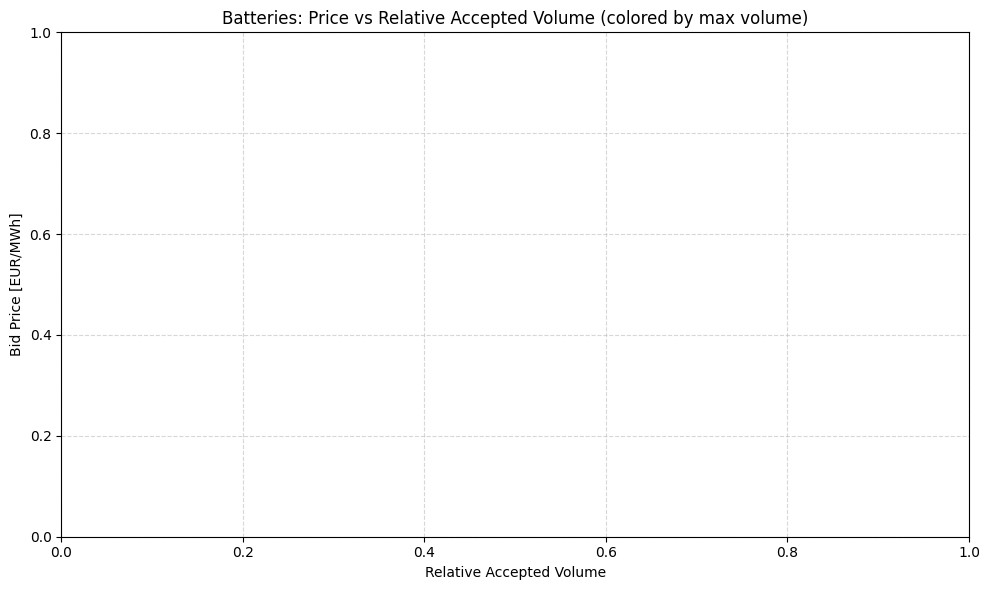

In [29]:
battery_ids = [uid for uid, typ in (unit_mapping.items() if "unit_mapping" in dir() else []) if typ == "battery"]

battery_max_volumes = {
    battery_id: market_orders[market_orders["bid_id"] == battery_id + "_1"]["volume"].max()
    for battery_id in battery_ids
}

max_vols = np.array([v if not np.isnan(v) else 0 for v in battery_max_volumes.values()])
norm = (max_vols - max_vols.min()) / (max_vols.max() - max_vols.min() + 1e-9) if len(max_vols) else max_vols
cmap = LinearSegmentedColormap.from_list("pink_turquoise", ["#ff69b4", "#5630d5"])

fig, ax = plt.subplots(figsize=(10, 6))
for idx, battery_id in enumerate(battery_ids):
    df_b = market_orders[market_orders["bid_id"] == battery_id + "_1"]
    if df_b.empty:
        continue
    max_vol = battery_max_volumes[battery_id]
    if max_vol == 0 or np.isnan(max_vol):
        continue
    rel_volume = df_b["accepted_volume"] / max_vol
    ax.scatter(rel_volume, df_b["bid_price"], color=cmap(norm[idx]), alpha=0.7, s=10)

if len(max_vols):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=max_vols.min(), vmax=max_vols.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Battery Max Volume [MW]")

ax.set_xlabel("Relative Accepted Volume")
ax.set_ylabel("Bid Price [EUR/MWh]")
ax.set_title("Batteries: Price vs Relative Accepted Volume (colored by max volume)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()